# KITTI-360

## View poses in mat.txt

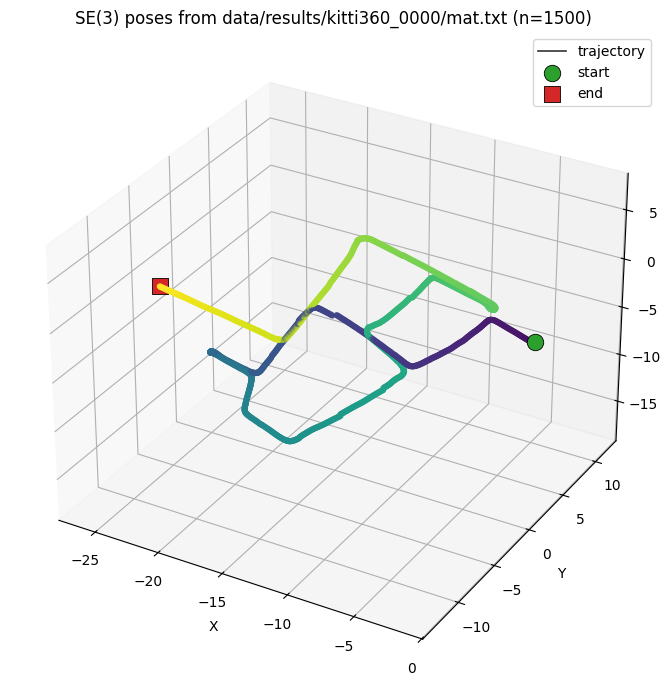

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 — registers 3d projection

###### Each row is a raveled 4x4 camera-to-world SE(3) matrix (see README / result_utils.save_results)
# est_se3_path = "data/results/replica_room2/mat.txt"
# est_se3_path = "data/results/waymo_152706/mat.txt"
est_se3_path = "data/results/kitti360_0000/mat.txt"


raw = np.loadtxt(est_se3_path)
if raw.ndim == 1:
    raw = raw.reshape(1, -1)

# print(raw.shape)
# select_num = 100
# raw = raw[:select_num]
# print(raw.shape)

n_frames, n_flat = raw.shape
assert n_flat == 16, f"expected 16 values per pose, got {n_flat}"
c2w = raw.reshape(n_frames, 4, 4)

# Camera origin in world coordinates
positions = c2w[:, :3, 3]

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")
ax.plot(positions[:, 0], positions[:, 1], positions[:, 2], "-", color="0.2", linewidth=1.2, label="trajectory")
ax.scatter(positions[:, 0], positions[:, 1], positions[:, 2], c=np.arange(n_frames), cmap="viridis", s=12, alpha=0.85)
ax.scatter(
    positions[0, 0],
    positions[0, 1],
    positions[0, 2],
    color="tab:green",
    s=140,
    marker="o",
    label="start",
    zorder=6,
    edgecolors="black",
    linewidths=0.6,
)
ax.scatter(
    positions[-1, 0],
    positions[-1, 1],
    positions[-1, 2],
    color="tab:red",
    s=140,
    marker="s",
    label="end",
    zorder=6,
    edgecolors="black",
    linewidths=0.6,
)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title(f"SE(3) poses from {est_se3_path} (n={n_frames})")
ax.legend(loc="upper right")

# Roughly equal aspect
lims = np.stack([positions.min(axis=0), positions.max(axis=0)], axis=1)
ctr = lims.mean(axis=1)
r = (lims[:, 1] - lims[:, 0]).max() / 2 + 1e-6
ax.set_xlim(ctr[0] - r, ctr[0] + r)
ax.set_ylim(ctr[1] - r, ctr[1] + r)
ax.set_zlim(ctr[2] - r, ctr[2] + r)

plt.tight_layout()
plt.show()

## Process KITTI-360 GT poses 

In [9]:
import numpy as np
from pathlib import Path

kitti_360_gt_dir = "/home/grl/datasets/KITTI-360/data_2d_raw/2013_05_28_drive_0000_sync"
gt_root = Path(kitti_360_gt_dir)
camstamp_path = gt_root / "camstamp.txt"
gt_local_path = gt_root / "gt_local.txt"
out_path = gt_root / "cam_tum.txt"

# gt_local.txt: STAMP tx ty tz qx qy qz qw
gt_stamps: list[float] = []
gt_poses: list[list[float]] = []
with open(gt_local_path, encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        parts = line.split()
        if len(parts) < 8:
            continue
        gt_stamps.append(float(parts[0]))
        gt_poses.append([float(x) for x in parts[1:8]])

gt_stamps_arr = np.asarray(gt_stamps, dtype=np.float64)
gt_poses_arr = np.asarray(gt_poses, dtype=np.float64)
order = np.argsort(gt_stamps_arr, kind="mergesort")
gt_stamps_arr = gt_stamps_arr[order]
gt_poses_arr = gt_poses_arr[order]


def nearest_tum_pose(stamp: float) -> np.ndarray:
    """Closest row in gt_local by absolute time difference (1D nearest neighbor on sorted stamps)."""
    i = int(np.searchsorted(gt_stamps_arr, stamp))
    if i <= 0:
        return gt_poses_arr[0]
    if i >= len(gt_stamps_arr):
        return gt_poses_arr[-1]
    d0 = abs(gt_stamps_arr[i - 1] - stamp)
    d1 = abs(gt_stamps_arr[i] - stamp)
    return gt_poses_arr[i - 1] if d0 <= d1 else gt_poses_arr[i]


# camstamp.txt: STAMP IMGNAME (one space split preserves IMGNAME if it contains spaces)
n_written = 0
with open(camstamp_path, encoding="utf-8") as fin, open(out_path, "w", encoding="utf-8") as fout:
    for line in fin:
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        stamp_str, imgname = line.split(None, 1)
        stamp = float(stamp_str)
        pose = nearest_tum_pose(stamp)
        pose_str = " ".join(f"{v:.8f}" for v in pose.tolist())
        fout.write(f"{stamp_str} {pose_str}\n")
        n_written += 1

print(f"Wrote {n_written} lines to {out_path}")


Wrote 11518 lines to /home/grl/datasets/KITTI-360/data_2d_raw/2013_05_28_drive_0000_sync/cam_tum.txt


## View KITTI-360 GT poses 

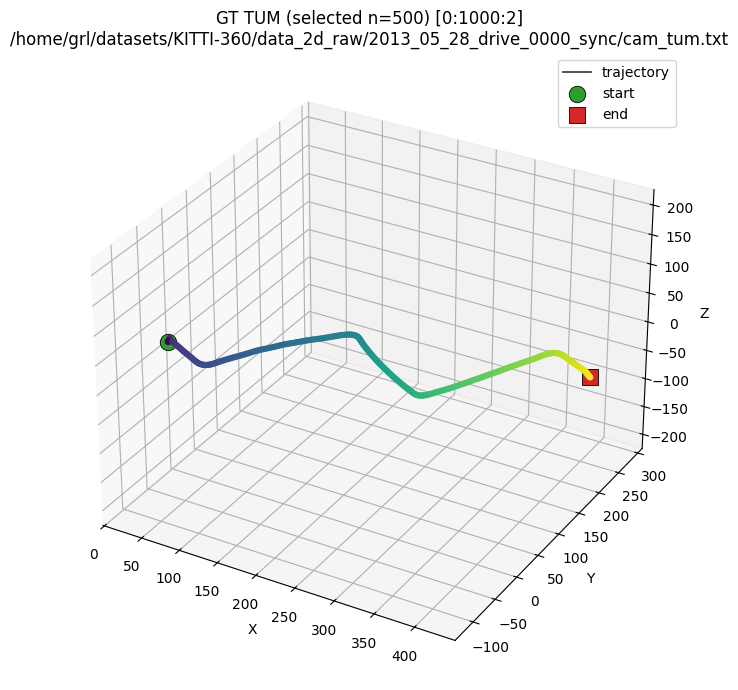

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 — registers 3d projection
from scipy.spatial.transform import Rotation

gt_tum_path = "/home/grl/datasets/KITTI-360/data_2d_raw/2013_05_28_drive_0000_sync/cam_tum.txt"

start_frame = 0
end_frame = 1000
interval = 2
# If True, each GT TUM pose is read as SE(3) then replaced with its inverse before evaluation.
should_invert_gt = False


def _tum7_to_c2w(pose7: np.ndarray) -> np.ndarray:
    """TUM pose vector tx ty tz qx qy qz qw -> 4x4 camera-to-world."""
    T = np.eye(4, dtype=np.float64)
    tx, ty, tz, qx, qy, qz, qw = pose7.tolist()
    T[:3, :3] = Rotation.from_quat([qx, qy, qz, qw]).as_matrix()
    T[:3, 3] = [tx, ty, tz]
    return T


poses7: list[np.ndarray] = []
with open(gt_tum_path, encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        parts = line.split()
        if len(parts) < 8:
            continue
        poses7.append(np.array([float(x) for x in parts[1:8]], dtype=np.float64))

if not poses7:
    raise ValueError(f"no valid TUM lines in {gt_tum_path}")

poses7_arr = np.stack(poses7, axis=0)
n_total = poses7_arr.shape[0]

indices = np.arange(start_frame, end_frame, interval, dtype=int)

c2w = np.stack([_tum7_to_c2w(poses7_arr[i]) for i in indices], axis=0)
if should_invert_gt:
    for k in range(len(c2w)):
        c2w[k] = np.linalg.inv(c2w[k])

# print(c2w.shape)
# select_num = 100
# c2w = c2w[:select_num]
# print(c2w.shape)


positions = c2w[:, :3, 3]
n_sel = positions.shape[0]

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")
ax.plot(positions[:, 0], positions[:, 1], positions[:, 2], "-", color="0.2", linewidth=1.2, label="trajectory")
ax.scatter(positions[:, 0], positions[:, 1], positions[:, 2], c=np.arange(n_sel), cmap="viridis", s=12, alpha=0.85)
ax.scatter(
    positions[0, 0],
    positions[0, 1],
    positions[0, 2],
    color="tab:green",
    s=140,
    marker="o",
    label="start",
    zorder=6,
    edgecolors="black",
    linewidths=0.6,
)
ax.scatter(
    positions[-1, 0],
    positions[-1, 1],
    positions[-1, 2],
    color="tab:red",
    s=140,
    marker="s",
    label="end",
    zorder=6,
    edgecolors="black",
    linewidths=0.6,
)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
inv_note = ", inverted" if should_invert_gt else ""
ax.set_title(
    f"GT TUM (selected n={n_sel}{inv_note}) [{start_frame}:{end_frame}:{interval}]\n{gt_tum_path}"
)
ax.legend(loc="upper right")

lims = np.stack([positions.min(axis=0), positions.max(axis=0)], axis=1)
ctr = lims.mean(axis=1)
r = (lims[:, 1] - lims[:, 0]).max() / 2 + 1e-6
ax.set_xlim(ctr[0] - r, ctr[0] + r)
ax.set_ylim(ctr[1] - r, ctr[1] + r)
ax.set_zlim(ctr[2] - r, ctr[2] + r)

plt.tight_layout()
plt.show()

## EVO: mat.txt and cam_tum.txt

len(est_se3): 500
len(gt_se3): 1500
len(timestamps): 1500
len(est_se3): 100
len(gt_se3): 100
len(timestamps): 100
--- ATE / alignment summary ---
poses compared: 1500 (indices 0:3000:2)
Umeyama scale factor: 19.77451366 (1.0 when correct_scale=False)
ATE RMSE (translation, m): 0.523861


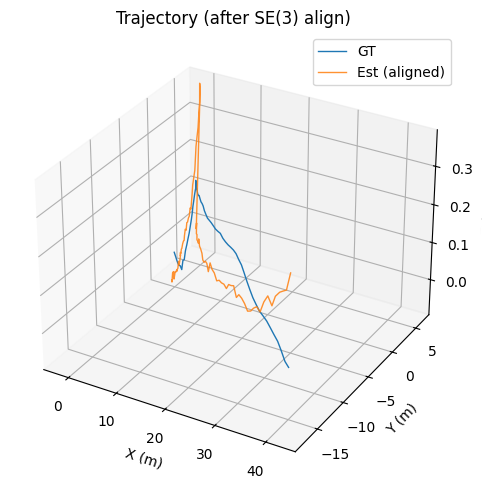

In [5]:
"""ATE vs GT: est mat.txt (16 floats c2w) vs standard TUM trajectory (stamp + tx ty tz qx qy qz qw). pip install evo."""
import copy
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.spatial.transform import Rotation
from evo.core.metrics import APE, PoseRelation, StatisticsType
from evo.core.trajectory import PoseTrajectory3D
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

est_se3_path = "data/results/kitti360_0000/mat.txt"
gt_tum_path = "/home/grl/datasets/KITTI-360/data_2d_raw/2013_05_28_drive_0000_sync/cam_tum.txt"

start_frame = 0
end_frame = 3000
interval = 2
# If True, each GT TUM pose is read as SE(3) then replaced with its inverse before evaluation.
should_invert_gt = False


def _tum_row_to_se3(tx: float, ty: float, tz: float, qx: float, qy: float, qz: float, qw: float) -> np.ndarray:
    """TUM line: tx ty tz qx qy qz qw -> 4x4 SE(3)."""
    T = np.eye(4, dtype=np.float64)
    T[:3, :3] = Rotation.from_quat([qx, qy, qz, qw]).as_matrix()
    T[:3, 3] = [tx, ty, tz]
    return T


def _se3_to_tum_pose7(T: np.ndarray) -> np.ndarray:
    """4x4 SE(3) -> tx ty tz qx qy qz qw (TUM quaternion order, scipy / evo compatible)."""
    t = T[:3, 3].astype(np.float64)
    qx, qy, qz, qw = Rotation.from_matrix(T[:3, :3].astype(np.float64)).as_quat()
    return np.array([t[0], t[1], t[2], qx, qy, qz, qw], dtype=np.float64)


def _parse_tum_trajectory_line(line: str) -> tuple[float, np.ndarray] | None:
    """Standard TUM: STAMP tx ty tz qx qy qz qw (8 whitespace-separated fields)."""
    line = line.strip()
    if not line or line.startswith("#"):
        return None
    parts = line.split()
    if len(parts) < 8:
        return None
    stamp = float(parts[0])
    pose = np.array([float(x) for x in parts[1:8]], dtype=np.float64)
    return stamp, pose


def _load_gt_tum(path: str | Path, should_invert: bool = False) -> tuple[list[float], list[np.ndarray]]:
    stamps: list[float] = []
    poses7: list[np.ndarray] = []
    with open(path, encoding="utf-8") as f:
        for line in f:
            parsed = _parse_tum_trajectory_line(line)
            if parsed is None:
                continue
            stamp, pose = parsed
            if should_invert:
                T = _tum_row_to_se3(*pose.tolist())
                pose = _se3_to_tum_pose7(np.linalg.inv(T))
            stamps.append(stamp)
            poses7.append(pose)
    return stamps, poses7


# --- load full trajectories ---
est_raw = np.loadtxt(est_se3_path)
if est_raw.ndim == 1:
    est_raw = est_raw.reshape(1, -1)
if est_raw.shape[1] != 16:
    raise ValueError(f"expected 16 values per line in {est_se3_path}, got {est_raw.shape[1]}")

gt_stamps, gt_poses7 = _load_gt_tum(gt_tum_path, should_invert=should_invert_gt)
if len(gt_stamps) == 0:
    raise ValueError(f"no valid lines in {gt_tum_path}")

# --- same index set for est and GT: [start_frame : end_frame : interval] ---
indices = np.arange(start_frame, end_frame, interval, dtype=int)

est_se3 = [est_raw_i.reshape(4, 4).astype(np.float64) for est_raw_i in est_raw]
gt_se3 = [_tum_row_to_se3(*gt_poses7[i]) for i in indices]
timestamps = np.array([gt_stamps[i] for i in indices], dtype=np.float64)
print(f'len(est_se3): {len(est_se3)}')
print(f'len(gt_se3): {len(gt_se3)}')
print(f'len(timestamps): {len(timestamps)}')

select_num = 100
est_se3 = est_se3[:select_num]
gt_se3 = gt_se3[:select_num]
timestamps = timestamps[:select_num]
print(f'len(est_se3): {len(est_se3)}')
print(f'len(gt_se3): {len(gt_se3)}')
print(f'len(timestamps): {len(timestamps)}')


traj_ref = PoseTrajectory3D(poses_se3=gt_se3, timestamps=timestamps)
traj_est = PoseTrajectory3D(poses_se3=est_se3, timestamps=timestamps)

# SE(3) Umeyama alignment: returns rotation R_a, translation t_a, scale s from Umeyama
traj_est_aligned = copy.deepcopy(traj_est)
R_align, t_align, scale_umeyama = traj_est_aligned.align(
    traj_ref, 
    correct_scale=True,
    # correct_only_scale=True,
    correct_only_scale=False,
)

ape = APE(PoseRelation.translation_part)
ape.process_data((traj_ref, traj_est_aligned))

stats = ape.get_all_statistics()
rmse = stats.get("rmse", ape.get_statistic(StatisticsType.rmse))

print("--- ATE / alignment summary ---")
print(f"poses compared: {len(indices)} (indices {start_frame}:{end_frame}:{interval})")
print(f"Umeyama scale factor: {float(scale_umeyama):.8f} (1.0 when correct_scale=False)")
print(f"ATE RMSE (translation, m): {stats.get('rmse', float('nan')):.6f}")
# for key in ("mean", "median", "std", "min", "max"):
#     if key in stats:
#         print(f"ATE {key} (m): {stats[key]:.6f}")

# --- plots ---
pref = traj_ref.positions_xyz
pest = traj_est_aligned.positions_xyz
err_m = np.asarray(ape.error, dtype=np.float64)

fig = plt.figure(figsize=(11, 5))

ax1 = fig.add_subplot(1, 1, 1, projection="3d")
ax1.plot(pref[:, 0], pref[:, 1], pref[:, 2], label="GT", color="C0", linewidth=1.0)
ax1.plot(pest[:, 0], pest[:, 1], pest[:, 2], label="Est (aligned)", color="C1", linewidth=1.0, alpha=0.85)
ax1.set_xlabel("X (m)")
ax1.set_ylabel("Y (m)")
ax1.set_zlabel("Z (m)")
ax1.set_title("Trajectory (after SE(3) align)")
ax1.legend(loc="upper right")

plt.tight_layout()
plt.show()

# TUM

## Build EST_TRAJ and GT_TRAJ

In [1]:
# scene_name = "room"
# scene_name = "xyz"
scene_name = "desk"

In [2]:
"""Build EST_TRAJ (est poses + rgb timestamps, sliced) and GT_TRAJ (nearest GT pose per EST stamp)."""
import numpy as np
from scipy.spatial.transform import Rotation

print(f"scene_name: {scene_name}")
est_se3_path = f"data/results/tum_fr1_{scene_name}/mat.txt"
stamp_rgb_path = f"/home/grl/datasets/tum/rgbd_dataset_freiburg1_{scene_name}/rgb.txt"
gt_tum_redundant_path = f"/home/grl/datasets/tum/rgbd_dataset_freiburg1_{scene_name}/groundtruth.txt"

if scene_name == "room":
    start_frame = 0
    end_frame = -1
    interval = 5
elif scene_name == "xyz":
    start_frame = 0
    end_frame = -1
    interval = 10  # 3
elif scene_name == "desk":
    start_frame = 0
    end_frame = -1
    interval = 2


def _tum7_to_c2w(pose7: np.ndarray) -> np.ndarray:
    T = np.eye(4, dtype=np.float64)
    tx, ty, tz, qx, qy, qz, qw = pose7.tolist()
    T[:3, :3] = Rotation.from_quat([qx, qy, qz, qw]).as_matrix()
    T[:3, 3] = [tx, ty, tz]
    return T


def _load_stamp_rgb(path: str) -> tuple[list[float], list[str]]:
    stamps: list[float] = []
    names: list[str] = []
    with open(path, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            parts = line.split()
            if len(parts) < 2:
                continue
            stamps.append(float(parts[0]))
            names.append(parts[1])
    return stamps, names


def _load_gt_tum_redundant(path: str) -> tuple[np.ndarray, np.ndarray]:
    """Returns (stamps (N,), poses7 (N,7)) sorted by stamp."""
    stamps: list[float] = []
    rows: list[list[float]] = []
    with open(path, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            parts = line.split()
            if len(parts) < 8:
                continue
            stamps.append(float(parts[0]))
            rows.append([float(x) for x in parts[1:8]])
    s = np.asarray(stamps, dtype=np.float64)
    p = np.asarray(rows, dtype=np.float64)
    order = np.argsort(s, kind="mergesort")
    return s[order], p[order]


def _nearest_gt_pose(gt_stamps: np.ndarray, gt_poses7: np.ndarray, t: float) -> tuple[float, np.ndarray]:
    i = int(np.searchsorted(gt_stamps, t))
    if i <= 0:
        return float(gt_stamps[0]), gt_poses7[0].copy()
    if i >= len(gt_stamps):
        return float(gt_stamps[-1]), gt_poses7[-1].copy()
    d0 = abs(gt_stamps[i - 1] - t)
    d1 = abs(gt_stamps[i] - t)
    j = i - 1 if d0 <= d1 else i
    return float(gt_stamps[j]), gt_poses7[j].copy()


rgb_stamps, rgb_names = _load_stamp_rgb(stamp_rgb_path)
n_rgb = len(rgb_stamps)
if n_rgb == 0:
    raise ValueError(f"no rgb lines in {stamp_rgb_path}")
print(f"n_rgb: {n_rgb}")

est_raw = np.loadtxt(est_se3_path)
if est_raw.ndim == 1:
    est_raw = est_raw.reshape(1, -1)
if est_raw.shape[1] != 16:
    raise ValueError(f"expected 16 values per line in {est_se3_path}")
n_est = est_raw.shape[0]
print(f"n_est: {n_est}")

stop = n_rgb if int(end_frame) < 0 else min(int(end_frame), n_rgb)
indices = np.arange(int(start_frame), int(stop), int(interval), dtype=int)
print(f"indices: {indices}")
if int(interval) <= 0:
    raise ValueError("interval must be positive")
if len(indices) == 0:
    raise ValueError("empty slice [start_frame:end_frame:interval]; check bounds")
assert len(indices) == n_est, f"len(indices): {len(indices)}, n_est: {n_est}"

EST_TRAJ = {
    "timestamps": np.asarray(
        [rgb_stamps[i] for i in indices], 
        dtype=np.float64
    ),
    "poses_c2w": np.stack(
        [est_raw_i.reshape(4, 4).astype(np.float64) for est_raw_i in est_raw], 
        axis=0
    ),
}

gt_stamps_full, gt_poses7_full = _load_gt_tum_redundant(gt_tum_redundant_path)
if len(gt_stamps_full) == 0:
    raise ValueError(f"no GT lines in {gt_tum_redundant_path}")

matched_gt_stamps = []
matched_gt_poses7 = []
matched_gt_c2w = []
for t in EST_TRAJ["timestamps"]:
    gs, p7 = _nearest_gt_pose(gt_stamps_full, gt_poses7_full, float(t))
    matched_gt_stamps.append(gs)
    matched_gt_c2w.append(_tum7_to_c2w(p7))

GT_TRAJ = {
    "timestamps": np.asarray(matched_gt_stamps, dtype=np.float64),
    "poses_c2w": np.stack(matched_gt_c2w, axis=0),
}

print(
    f"EST_TRAJ: n={len(EST_TRAJ['timestamps'])}, "
    f"t0..tn = {EST_TRAJ['timestamps'][0]:.6f} .. {EST_TRAJ['timestamps'][-1]:.6f}"
)
print(
    f"GT_TRAJ: n={len(GT_TRAJ['timestamps'])}, "
    f"t0..tn = {GT_TRAJ['timestamps'][0]:.6f} .. {GT_TRAJ['timestamps'][-1]:.6f}"
)
print(
    f"mean |dt_est - dt_gt| = {np.mean(np.abs(EST_TRAJ['timestamps'] - GT_TRAJ['timestamps'])):.6f} s"
)

scene_name: desk
n_rgb: 613
n_est: 307
indices: [  0   2   4   6   8  10  12  14  16  18  20  22  24  26  28  30  32  34
  36  38  40  42  44  46  48  50  52  54  56  58  60  62  64  66  68  70
  72  74  76  78  80  82  84  86  88  90  92  94  96  98 100 102 104 106
 108 110 112 114 116 118 120 122 124 126 128 130 132 134 136 138 140 142
 144 146 148 150 152 154 156 158 160 162 164 166 168 170 172 174 176 178
 180 182 184 186 188 190 192 194 196 198 200 202 204 206 208 210 212 214
 216 218 220 222 224 226 228 230 232 234 236 238 240 242 244 246 248 250
 252 254 256 258 260 262 264 266 268 270 272 274 276 278 280 282 284 286
 288 290 292 294 296 298 300 302 304 306 308 310 312 314 316 318 320 322
 324 326 328 330 332 334 336 338 340 342 344 346 348 350 352 354 356 358
 360 362 364 366 368 370 372 374 376 378 380 382 384 386 388 390 392 394
 396 398 400 402 404 406 408 410 412 414 416 418 420 422 424 426 428 430
 432 434 436 438 440 442 444 446 448 450 452 454 456 458 460 462 464 466
 46

## EVO

--- ATE (EST_TRAJ vs GT_TRAJ) ---
poses: 307
Umeyama scale: 1.10974746
ATE RMSE (translation, m): 0.051915


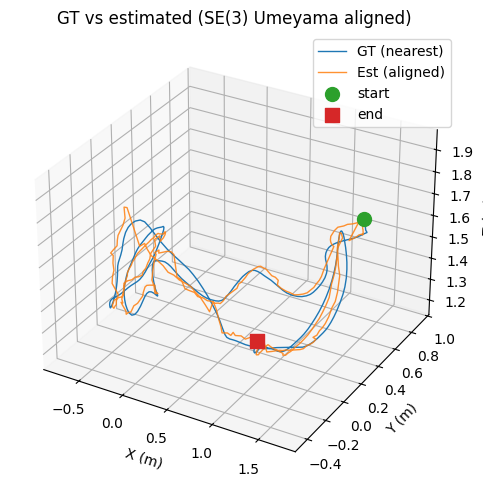

In [3]:
"""ATE between EST_TRAJ and GT_TRAJ (requires prior cell + pip install evo)."""
import copy

import matplotlib.pyplot as plt
import numpy as np
from evo.core.metrics import APE, PoseRelation, StatisticsType
from evo.core.trajectory import PoseTrajectory3D
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

if "EST_TRAJ" not in dir() or "GT_TRAJ" not in dir():
    raise RuntimeError("Run the cell that defines EST_TRAJ and GT_TRAJ first.")

est_ts = EST_TRAJ["timestamps"]
est_poses = [np.asarray(p, dtype=np.float64) for p in EST_TRAJ["poses_c2w"]]
gt_ts = GT_TRAJ["timestamps"]
gt_poses = [np.asarray(p, dtype=np.float64) for p in GT_TRAJ["poses_c2w"]]

if len(est_ts) != len(gt_ts):
    raise ValueError(f"length mismatch: EST {len(est_ts)} vs GT {len(gt_ts)}")

traj_ref = PoseTrajectory3D(poses_se3=gt_poses, timestamps=np.asarray(gt_ts, dtype=np.float64))
traj_est = PoseTrajectory3D(poses_se3=est_poses, timestamps=np.asarray(est_ts, dtype=np.float64))

traj_est_aligned = copy.deepcopy(traj_est)
_, t_align, scale_umeyama = traj_est_aligned.align(
    traj_ref, 
    correct_scale=True,
    correct_only_scale=False,
)

ape = APE(PoseRelation.translation_part)
ape.process_data((traj_ref, traj_est_aligned))
stats = ape.get_all_statistics()
rmse = float(stats.get("rmse", ape.get_statistic(StatisticsType.rmse)))

print("--- ATE (EST_TRAJ vs GT_TRAJ) ---")
print(f"poses: {len(est_ts)}")
print(f"Umeyama scale: {float(scale_umeyama):.8f}")
# print(f"alignment t (m): {np.asarray(t_align).ravel()}")
print(f"ATE RMSE (translation, m): {rmse:.6f}")
# for key in ("mean", "median", "std", "min", "max"):
#     if key in stats:
#         print(f"ATE {key} (m): {stats[key]:.6f}")

pref = traj_ref.positions_xyz
pest = traj_est_aligned.positions_xyz
err_m = np.asarray(ape.error, dtype=np.float64)

fig = plt.figure(figsize=(11, 5))
ax1 = fig.add_subplot(1, 1, 1, projection="3d")
ax1.plot(pref[:, 0], pref[:, 1], pref[:, 2], label="GT (nearest)", color="C0", linewidth=1.0)
ax1.plot(pest[:, 0], pest[:, 1], pest[:, 2], label="Est (aligned)", color="C1", linewidth=1.0, alpha=0.85)
ax1.scatter(pref[0, 0], pref[0, 1], pref[0, 2], color="tab:green", s=100, marker="o", label="start", zorder=5)
ax1.scatter(pref[-1, 0], pref[-1, 1], pref[-1, 2], color="tab:red", s=100, marker="s", label="end", zorder=5)
ax1.set_xlabel("X (m)")
ax1.set_ylabel("Y (m)")
ax1.set_zlabel("Z (m)")
ax1.set_title("GT vs estimated (SE(3) Umeyama aligned)")
ax1.legend(loc="upper right")

plt.tight_layout()
plt.show()